In [6]:
import numpy as np
import jax.numpy as jnp

from fbpinns.domains import RectangularDomainND
from fbpinns.problems import Problem
from fbpinns.decompositions import RectangularDecompositionND
from fbpinns.networks import FCN
from fbpinns.constants import Constants

domain = RectangularDomainND

domain_init_kwargs = dict(
    xmin=np.array([0.,0.]),
    xmax=np.array([1.,1.]),
)

class HomogeneousLaplacian2D(Problem):

    @staticmethod
    def init_params(sigma=0.2):
    
        static_params = {
            "dims": (1, 2),
            "sigma": sigma,
        }
    
        return static_params, {}

    @staticmethod
    def sample_constraints(all_params, domain, key, sampler, batch_shapes):

        x_batch_phys = domain.sample_interior(all_params, key, sampler, batch_shapes[0])

        required_ujs_phys = (
            (0, ()),
            (0, (0, 0)),
            (0, (1, 1)),
        )

        return [[x_batch_phys, required_ujs_phys]]

    @staticmethod
    def loss_fn(all_params, constraints):

        x_batch, u, u_xx, u_yy = constraints[0]

        x = x_batch[:, 0:1]
        y = x_batch[:, 1:2]

        f = 32.0 * (x * (1.0 - x) + y * (1.0 - y))

        phys = jnp.mean((-u_xx - u_yy - f) ** 2)

        return phys

    @staticmethod
    def constraining_fn(all_params, x_batch, u):

        sigma = all_params["static"]["problem"]["sigma"]

        x = x_batch[:, 0:1]
        y = x_batch[:, 1:2]

        c = (
            jnp.tanh(x / sigma)
            * jnp.tanh((1.0 - x) / sigma)
            * jnp.tanh(y / sigma)
            * jnp.tanh((1.0 - y) / sigma)
        )

        return c * u

    @staticmethod
    def exact_solution(all_params, x_batch, batch_shape=None):

        x = x_batch[:, 0:1]
        y = x_batch[:, 1:2]

        return 16.0 * x * (1.0 - x) * y * (1.0 - y)


problem = HomogeneousLaplacian2D
problem_init_kwargs = dict(
    sigma=0.2,
)

def build_decomposition(levels, delta=1.9):

    xs = []
    ws = []

    for L in levels:

        if L == 1:
            centers = np.array([0.5])
            widths = np.array([delta])
        else:
            centers = np.linspace(0,1,L)
            widths = np.ones(L) * (delta/(L-1))

        xs.append(centers)
        ws.append(widths)

    xs_all = np.concatenate(xs)
    ws_all = np.concatenate(ws)

    return dict(
        subdomain_xs=[xs_all, xs_all],
        subdomain_ws=[ws_all, ws_all],
        unnorm=(0.0,1.0)
    )

cases = {
    "levels_1_2_4":[1,2,4],
    "levels_4":[4],
    "levels_1_2":[1,2],
    "levels_2":[2],
}

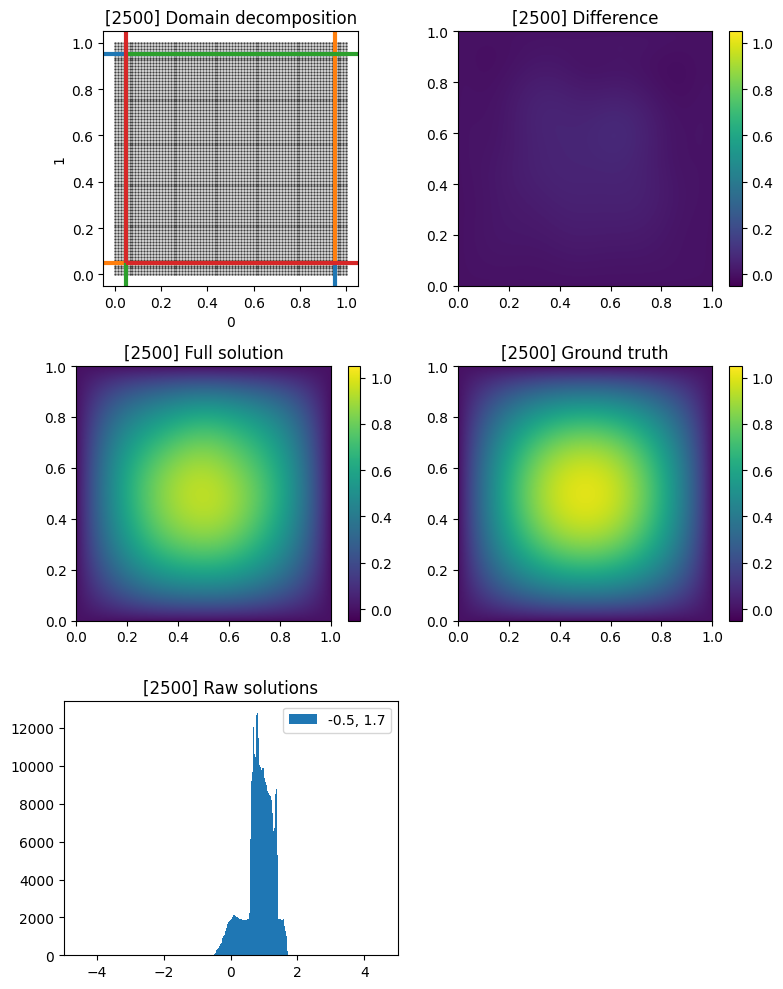

[INFO] 2026-03-12 16:53:17 - [i: 2500/2500] Training complete


In [8]:
for name, levels in cases.items():

    decomposition_init_kwargs = build_decomposition(levels)

    c = Constants(
        run=name,

        domain=domain,
        domain_init_kwargs=domain_init_kwargs,

        problem=problem,
        problem_init_kwargs=problem_init_kwargs,

        decomposition=RectangularDecompositionND,
        decomposition_init_kwargs=decomposition_init_kwargs,

        network=FCN,
        network_init_kwargs=dict(layer_sizes=[2,16,1]),

        ns=((80,80),),
        n_test=(350,350),

        n_steps=15000,
        summary_freq=200,
        test_freq=200,
        clear_output=True,
    )

    trainer = FBPINNTrainer(c)
    trainer.train()